# Read UK radar data from NIMROD format 
**Launch this notebook:**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Thomasjkeel/access-UK-radar-data/blob/main/from_file/read_radar_data_from_file.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/Thomasjkeel/access-UK-radar-data/HEAD)

---

**Setup**
Let's load the python libraries we need to read this data.  
If required, you can install required packages by uncommenting and running the cell below...

In [1]:
# %%capture
# !pip install xarray[io] rioxarray rasterio matplotlib numpy geopandas

In [2]:
# Python standard libraries
import gzip
import io
import os
import tarfile

# 3rd party libraries
import numpy as np
import pandas as pd
import rioxarray
import geopandas as gpd
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

# local files (downloaded from https://github.com/richard-thomas/MetOffice_NIMROD/tree/master)
import nimrod

# Introduction
In this short tutorial, we will go through how to load in and subset UK radar images which can be downloaded from the CEDA Archive at 5 or 15 min resolutions and on 1 km, 2 km and 5 km grids ([link](https://catalogue.ceda.ac.uk/uuid/82adec1f896af6169112d09cc1174499/?q=&results_per_page=20&sort_by=title_desc&objects_related_to_uuid=82adec1f896af6169112d09cc1174499&page=3)). This data is in NIMROD format (docs [here](https://data.ceda.ac.uk/badc/ukmo-nimrod/doc)).

For this tutorial, we have provided a single day of data: 1 km resolution UK Composite rainfall data at 5-min for the 9th October 2023, but you can download more data from the CEDA Archive e.g. [1 km Resolution UK Composite Rainfall Data from the Met Office Nimrod System](https://data.ceda.ac.uk/badc/ukmo-nimrod/data/composite/uk-1km/). More info is provided about using more data (or data from JASMIN) at the bottom of this notebook (Section 7).

## Gallery (visualisations from this notebook)
<p float="left">
    <img src="https://raw.githubusercontent.com/Thomasjkeel/access-UK-radar-data/refs/heads/main/figures/UK_rain_from_radar_5min.png" alt="5min-mean" style="width:250px;"/>
    <img src="https://raw.githubusercontent.com/Thomasjkeel/access-UK-radar-data/refs/heads/main/figures/UK_rain_from_radar_1h_mean.png" alt="1h-mean" style="width:250px;" />
</p>

<p float="left">
    <img src="https://raw.githubusercontent.com/Thomasjkeel/access-UK-radar-data/refs/heads/main/figures/severn_catchment_subset_1h_mean.png" alt="catch-subset" style="width:500px;"/>  
</p>

<p float="left">
    <img src="https://raw.githubusercontent.com/Thomasjkeel/access-UK-radar-data/refs/heads/main/figures/catchment_mean_rainfall.png" alt="catch-subset" style="width:500px;" />
</p>


### Table of contents
1. Extract NIMROD images to ascii format   
2. Look at a single 5 min time step
3. Look at entire day of 5 min time steps
4. Plot data with Cartopy
5. Resample data to hourly
6. Subset data to river catchment boundary 
7. Advice for reading in more data


# 1. Extract NIMROD images to ascii format 

Reading the radar data from NIMROD format image files is not easy: it is an awkward format. It can, however, be converted to ascii, which we can then read into [xarray Datasets](https://docs.xarray.dev/en/stable/index.html).

If you have downloaded this notebook from GitHub, the folder "NIMROD_UK_composite_1km" contains a compressed data archive for a single day: 9th October 2023. Let's load that data in.

If you use different data, please change the following folder path & gzip_name as appropriate below.


In [3]:
DATE_TO_USE = "20231009" # Select 9th October 2023

# Data locations and names
PATH_TO_NIMROD_FOLDER =  "NIMROD_UK_composite_1km/" # location of example data
GZIP_DATA_NAME = "metoffice-c-band-rain-radar_uk_{0}_1km-composite.dat.gz.tar" # will be different depending on dataset
OUTPUT_FOLDER = "formatted_NIMROD_data/" # We'll save the extracted ascii files here

In [4]:
# create the output directory
if not os.path.exists(OUTPUT_FOLDER):
    print("Creating output directory!")
    os.makedirs(OUTPUT_FOLDER, exist_ok=False)

Next, let's extract the individual 5 min timesteps from that day, and extract them out to ascii format:

In [5]:
all_dates_to_process = [DATE_TO_USE] # This list only contains one date for now

In [6]:
# ~10 mins per single day file and each are 3 GB (note: timings are resource-dependent)
OVERWRITE_FILES = False # set this to True if you want to overwrite files
for date_to_process in all_dates_to_process:
    tar_path = os.path.join(
        PATH_TO_NIMROD_FOLDER,
        GZIP_DATA_NAME.format(date_to_process)
    )

    # Create folder for this date
    output_dir = os.path.join(OUTPUT_FOLDER, str(date_to_process))
    if os.path.exists(output_dir):
        print(output_dir, "already exists")
        if not OVERWRITE_FILES: 
            continue
        else:
            print("Overwriting...")
    else:
        os.makedirs(output_dir, exist_ok=False)

    with tarfile.open(tar_path, "r") as tar:
        for member in tar:
            if member.isfile() and member.name.endswith(".dat.gz"):
                print(f"Extracting: {member.name}...")
                with tar.extractfile(member) as gz_stream:
                    with gzip.GzipFile(fileobj=gz_stream) as dat_stream:
                        dat_bytes = dat_stream.read()
                        nimrod_data = nimrod.Nimrod(io.BytesIO(dat_bytes))

                        base_name = os.path.basename(member.name[:-7])  # remove .dat.gz
                        out_path = os.path.join(output_dir, f"{base_name}.asc")

                        with open(out_path, "w") as out_file:
                            nimrod_data.extract_asc(out_file)

formatted_NIMROD_data/20231009 already exists


# 2. Read one time step
Let's have a look at a single 5 minute timestep, i.e. at 02:00

In [7]:
example_nimrod_raster = xr.open_dataarray(
    os.path.join(OUTPUT_FOLDER, all_dates_to_process[0], "metoffice-c-band-rain-radar_uk_202310090200_1km-composite.asc")
)

In [8]:
example_nimrod_raster.load()

<xarray.DataArray 'band_data' (band: 1, y: 2175, x: 1725)> Size: 15MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(1, 2175, 1725), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 17kB 1.55e+06 1.548e+06 ... -6.235e+05 -6.245e+05
  * x            (x) float64 14kB -4.045e+05 -4.035e+05 ... 1.318e+06 1.32e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point

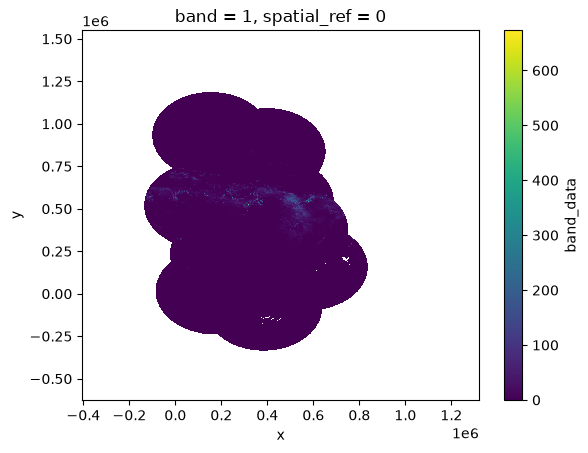

In [9]:
example_nimrod_raster.plot()

## 3. Load an entire day of 5-min time steps
Next, let's see how you can load in the entire day of data. To do this, we'll rely on xarray's 'lazy loading'. That is, we will not load the full data of data into memory just yet.

In [10]:
print(DATE_TO_USE)

20231009


In [11]:
# open_mfdataset is going to handle combining the individual time steps
one_day_nimrod = xr.open_mfdataset(os.path.join(OUTPUT_FOLDER, DATE_TO_USE, "*"), combine='nested', concat_dim='time', engine='rasterio')

In [12]:
# Let's re-chunk the data so it is in a safer format
print("Chunks before:", one_day_nimrod.chunks)
one_day_nimrod = one_day_nimrod.chunk({
    "time": 24,
    "band": 1,
    "y": 512,
    "x": 512,
})
print("Chunks after:", one_day_nimrod.chunks)

Chunks before: Frozen({'time': (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1), 'band': (1,), 'y': (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [13]:
# Let's rename the data and set a unit name
one_day_nimrod = one_day_nimrod.rename({'band_data': 'rainfall_rate'})
one_day_nimrod['rainfall_rate']['units'] = "mm/hr"

We'll plot out a single time step to see how the data looks: 

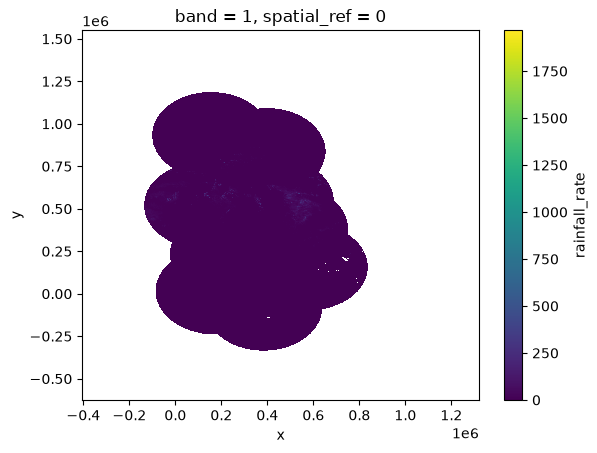

In [14]:
one_day_nimrod.isel(time=0)['rainfall_rate'].plot()

Hmm, there's lots of blank space, let's clip the domain so there is less

In [15]:
# Let's clip the domain so there are less blank spaces
one_day_nimrod_clip = one_day_nimrod.sel(x=slice(None, 900_000), y=slice(1_250_000, -400_000))

### Sorting out time dimension for the multi-image dataset
If you haven't seen already, the 'time' dimension of our dataset runs between 0-287, we'll need to change that so that it represents the 5-min time steps from 00:00 to 23:55. 

Because the data will be loaded by `xr.open_mfdataset` in filename order, we know that the 'time' dim will run 00:00 to 23:55. You could also confirm this by looking in the `formatted_NIMROD_data` folder. 

In [16]:
# time dim (before formatting)
one_day_nimrod_clip['time'].load().values

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

Let's format the time dim now...  

*Note: you could be safer with this reformatting if you wanted to be clever*  

In [17]:
dates = pd.date_range(
    start=f"{DATE_TO_USE[:4]}-{DATE_TO_USE[4:6]}-{DATE_TO_USE[6:8]} 00:00",
    end=f"{DATE_TO_USE[:4]}-{DATE_TO_USE[4:6]}-{DATE_TO_USE[6:8]} 23:55",
    freq="5min"
)

one_day_nimrod_clip['time'] = dates

# data was scaled up by 32
one_day_nimrod_clip['rainfall_rate'] = one_day_nimrod_clip['rainfall_rate'] / 32

In [18]:
one_day_nimrod_clip['time']

<xarray.DataArray 'time' (time: 288)> Size: 2kB
array(['2023-10-09T00:00:00.000000', '2023-10-09T00:05:00.000000',
       '2023-10-09T00:10:00.000000', ..., '2023-10-09T23:45:00.000000',
       '2023-10-09T23:50:00.000000', '2023-10-09T23:55:00.000000'],
      shape=(288,), dtype='datetime64[us]')
Coordinates:
  * time         (time) datetime64[us] 2kB 2023-10-09 ... 2023-10-09T23:55:00
    spatial_ref  int64 8B 0

Now that is formatted, let's load the data into local memory with `.load()`

In [19]:
%%time
# Takes 5-15 mins (timing is resource-dependent)
one_day_nimrod_clip.load()

CPU times: user 15min 1s, sys: 50.6 s, total: 15min 52s
Wall time: 13min 46s


<xarray.Dataset> Size: 2GB
Dimensions:        (time: 288, band: 1, y: 1650, x: 1305)
Coordinates:
  * time           (time) datetime64[us] 2kB 2023-10-09 ... 2023-10-09T23:55:00
  * band           (band) int64 8B 1
  * y              (y) float64 13kB 1.25e+06 1.248e+06 ... -3.985e+05 -3.995e+05
  * x              (x) float64 10kB -4.045e+05 -4.035e+05 ... 8.995e+05
    spatial_ref    int64 8B 0
Data variables:
    rainfall_rate  (time, band, y, x) float32 2GB nan nan nan ... nan nan nan

# 4. Plot data
Next, let's plot the data onto an outline of the British Isles

In [20]:
# British National Grid projection (crs==27700)
bng = ccrs.TransverseMercator(
    central_longitude=-2.0,  ## +lon_0
    central_latitude=49.0,      # +lat_0
    scale_factor=0.999601,      # +k
    false_easting=400000.0,     # +x_0
    false_northing=-100000.0,   # +y_0
    globe=ccrs.Globe(ellipse='airy')  # +ellps=airy
)


In [21]:
date_time_to_examine = "2023-10-09 02:30" # feel free to look at another datetime

Text(0.38, 0.28, 'NIMROD composite')

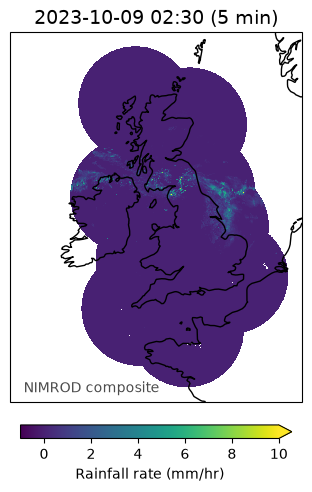

In [22]:
fig, ax = plt.subplots(1, subplot_kw={'projection': bng}, figsize=(10, 6))
one_day_radar = one_day_nimrod_clip.sel(time=date_time_to_examine)
one_day_radar['rainfall_rate'].plot(
    vmin=-1, vmax=10, ax=ax, 
    add_colorbar=True, cbar_kwargs={'orientation': 'horizontal', 'shrink': 0.35, 'pad': 0.05, 'label': 'Rainfall rate (mm/hr)'},
    transform=bng)
ax.coastlines();
ax.set_title(f"{date_time_to_examine} (5 min)", size=14);
fig.text(s="NIMROD composite", x=.38, y=.28, c='k', alpha=.7)
# fig.savefig("../../figures/UK_rain_from_radar_5min.png", bbox_inches='tight', dpi=150)

# 5. Resample to hourly
Let's coarsen the 5 min images to 1 hour with xarray's `.resample` method...

In [23]:
one_day_nimrod_clip_hourly = one_day_nimrod_clip.resample(
    time="1h",
    closed="left"
).mean()

In [24]:
hour_date_time_to_examine = "2023-10-09 02:00"

Text(0.38, 0.28, 'NIMROD composite')

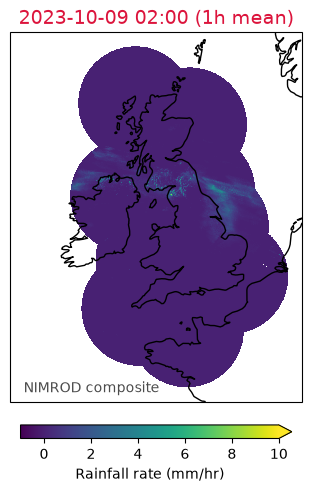

In [25]:
fig, ax = plt.subplots(1, subplot_kw={'projection': bng}, figsize=(10, 6))
one_day_radar_hourly = one_day_nimrod_clip_hourly.sel(time=hour_date_time_to_examine)
one_day_radar_hourly['rainfall_rate'].plot(
    vmin=-1, vmax=10, ax=ax, 
    add_colorbar=True, cbar_kwargs={'orientation': 'horizontal', 'shrink': 0.35, 'pad': 0.05, 'label': 'Rainfall rate (mm/hr)'},
    transform=bng)
ax.coastlines();
ax.set_title(f"{hour_date_time_to_examine} (1h mean)", size=14, color='crimson');
fig.text(s="NIMROD composite", x=.38, y=.28, c='k', alpha=.7)
# fig.savefig("../../figures/UK_rain_from_radar_1h_mean.png", bbox_inches='tight', dpi=150)

In [26]:
# If you'd like to save that date you can uncomment below...
one_day_nimrod_clip_hourly.to_netcdf(f'../../nimrod_hourly_resample_{DATE_TO_USE}.nc')

## 6. Subset to a river catchment
Because the data is in xarray format, we can mask out regions of it. Let's mask out a river catchment.

We'll use catchment boundary data from the National River Flow Archive ([NRFA](https://nrfa.ceh.ac.uk/)). Specifically, this example comes with a catchment boundary of the Severn at Haw Bridge ([ID: 54057](https://nrfa.ceh.ac.uk/data/station/info/54057)). 

In this next section, we are working with Shapefiles of catchment boundaries, which cannot be directly loaded into xarray, so we'll use a GeoTIFF file and the library [rasterio](https://corteva.github.io/rioxarray/stable/index.html) to leverage [rasterio](https://rasterio.readthedocs.io/en/latest/index.html) to create a 1km by 1km mask.

### Load in catchment boundary

In [27]:
# we'll use a buffer so the subset is not too tight to the boundary
CATCHMENT_BUFFER = 1500 # metres

In [28]:
# Read in catchment boundary for the River Severn at Haw Bridge
nrfa_shp = gpd.read_file("../../spatial_data/nrfa_54057/NRFA_catchments.shp")
print(nrfa_shp.bounds)

       minx      miny      maxx      maxy
0  281525.0  221825.0  469475.0  342725.0


<Axes: >

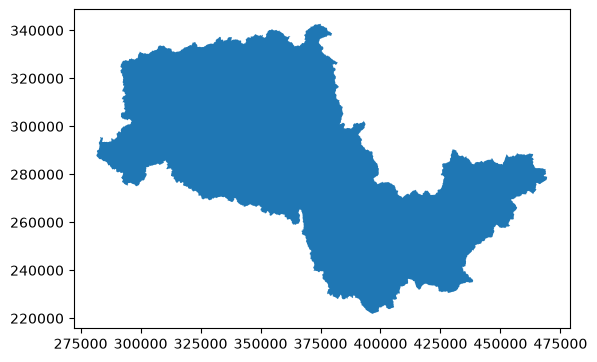

In [29]:
nrfa_shp.plot()

### Shift the data over by 500 meters so it can be used as a mask for the NIMROD images
Annoyingly, I forgot that the data from NIMROD images is on a 1 km grid that is offset by 500 m (e.g. 500, 1500, 2500), so to make it the same specifications as the height GeoTIFF, we'll need to shift it back

In [30]:
def shift_data_by_offset(radar_1d, var_name, shift_in_m=500):
    dx = shift_in_m
    dy = shift_in_m

    new_x = np.round(radar_1d['x']) + dx
    new_y = np.round(radar_1d['y']) + dy
    
    radar_1d = radar_1d.rio.write_crs("epsg:27700")

    shifted_radar = radar_1d.interp(x=new_x, y=new_y)
    shifted_radar = shifted_radar.assign_coords(x=new_x)
    shifted_radar = shifted_radar.assign_coords(y=new_y)
    shifted_radar[var_name] = shifted_radar[var_name].fillna(-1.)
    return shifted_radar

In [31]:
one_day_nimrod_clip_hourly

<xarray.Dataset> Size: 207MB
Dimensions:        (time: 24, band: 1, y: 1650, x: 1305)
Coordinates:
  * time           (time) datetime64[us] 192B 2023-10-09 ... 2023-10-09T23:00:00
  * band           (band) int64 8B 1
  * y              (y) float64 13kB 1.25e+06 1.248e+06 ... -3.985e+05 -3.995e+05
  * x              (x) float64 10kB -4.045e+05 -4.035e+05 ... 8.995e+05
    spatial_ref    int64 8B 0
Data variables:
    rainfall_rate  (time, band, y, x) float32 207MB nan nan nan ... nan nan nan

In [32]:
one_day_nimrod_clip_hourly_shifted = shift_data_by_offset(one_day_nimrod_clip_hourly, var_name="rainfall_rate")

In [33]:
one_day_nimrod_clip_hourly_shifted

<xarray.Dataset> Size: 413MB
Dimensions:        (time: 24, band: 1, y: 1650, x: 1305)
Coordinates:
  * time           (time) datetime64[us] 192B 2023-10-09 ... 2023-10-09T23:00:00
  * band           (band) int64 8B 1
  * y              (y) float64 13kB 1.25e+06 1.249e+06 ... -3.98e+05 -3.99e+05
  * x              (x) float64 10kB -4.04e+05 -4.03e+05 ... 8.99e+05 9e+05
    spatial_ref    int64 8B 0
Data variables:
    rainfall_rate  (time, band, y, x) float64 413MB -1.0 -1.0 -1.0 ... -1.0 -1.0

### Clip data to catchment bounds
To save memory, and compute time, we'll reduce the size of the radar composite to the bounds of the catchment boundary...

*NOTE: For the code below, some other data may not have a descending y-axis. Please check your data*

In [34]:
# Subset to bounds of given catchment 
catchment_nimrod_hourly = one_day_nimrod_clip_hourly_shifted.sel(
    x=slice(nrfa_shp.bounds['minx'][0]-CATCHMENT_BUFFER, nrfa_shp.bounds['maxx'][0]+CATCHMENT_BUFFER),
    y=slice(nrfa_shp.bounds['maxy'][0]+CATCHMENT_BUFFER, nrfa_shp.bounds['miny'][0]-CATCHMENT_BUFFER), # has to be reversed as y coordinates is descending
)
catchment_nimrod_hourly = catchment_nimrod_hourly.sortby("y")  # flip y coordinates


In [35]:
catchment_nimrod_hourly

<xarray.Dataset> Size: 5MB
Dimensions:        (time: 24, band: 1, y: 124, x: 190)
Coordinates:
  * time           (time) datetime64[us] 192B 2023-10-09 ... 2023-10-09T23:00:00
  * band           (band) int64 8B 1
  * y              (y) float64 992B 2.21e+05 2.22e+05 ... 3.43e+05 3.44e+05
  * x              (x) float64 2kB 2.81e+05 2.82e+05 ... 4.69e+05 4.7e+05
    spatial_ref    int64 8B 0
Data variables:
    rainfall_rate  (time, band, y, x) float64 5MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

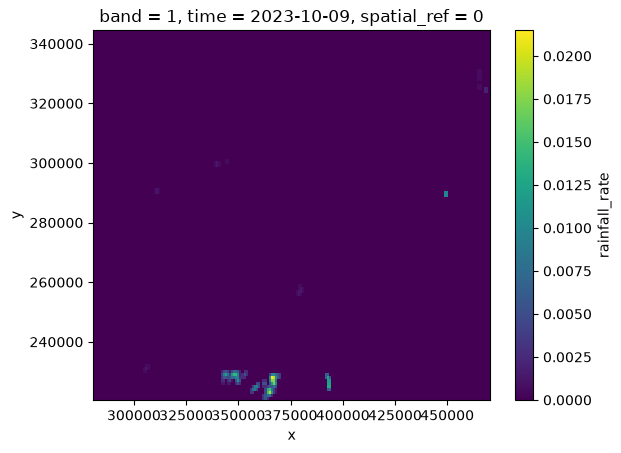

In [36]:
# plot out a single time step
catchment_nimrod_hourly.isel(time=0)['rainfall_rate'].plot()

### Clip the radar field based on the catchment boundary GeoTIFF
We'll introduce 2 small functions to clip the GeoTIFF based on the catchment boundary shapefile. 

In [37]:
def make_region_hght_clip(region_shp, hght_data):
    """Clip region by height raster"""
    region_clip = hght_data.rio.clip(
        region_shp.geometry.values, region_shp.crs, drop=False, invert=False
    )
    return region_clip


def binarize_hght_clip(region_data):
    """
    Make binary mask of clipped region data data
    """
    return region_data / region_data.where(region_data > 0)

In [38]:
# Load in a 1 km UK-wide GeoTIFF (in this case it is height data)
uk_hght = rioxarray.open_rasterio("../../spatial_data/uk_cehgear_mask.tif")

In [39]:
# Make catchment mask, and clip that catchment mask to the same bounds as the radar data
catchment_mask = make_region_hght_clip(nrfa_shp, uk_hght)

catchment_mask = catchment_mask.sel(
    x=slice(nrfa_shp.bounds['minx'][0]-CATCHMENT_BUFFER, nrfa_shp.bounds['maxx'][0]+CATCHMENT_BUFFER),
    y=slice(nrfa_shp.bounds['maxy'][0]+CATCHMENT_BUFFER, nrfa_shp.bounds['miny'][0]-CATCHMENT_BUFFER), 
)
catchment_mask = catchment_mask.isel(y=slice(None, None, -1)) # flip y coords

In [40]:
catchment_mask

<xarray.DataArray (band: 1, y: 124, x: 190)> Size: 188kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(1, 124, 190))
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 992B 2.21e+05 2.22e+05 ... 3.43e+05 3.44e+05
  * x            (x) float64 2kB 2.81e+05 2.82e+05 2.83e+05 ... 4.69e+05 4.7e+05
    spatial_ref  int64 8B 0
Attributes:
    long_name:      Gridded estimates of hourly rainfall
    standard_name:  rainfall_amount
    units:          kg m-2
    valid_max:      500.0
    valid_min:      0.0
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [1]:
# Plot it out and check the mask looks correct
fig, ax = plt.subplots(1)
catchment_mask.plot(ax=ax, alpha=.7, add_colorbar=False)
ax.set_xlim(nrfa_shp.bounds['minx'][0]-CATCHMENT_BUFFER, nrfa_shp.bounds['maxx'][0]+CATCHMENT_BUFFER);
ax.set_ylim(nrfa_shp.bounds['miny'][0]-CATCHMENT_BUFFER, nrfa_shp.bounds['maxy'][0]+CATCHMENT_BUFFER);
plt.show()


NameError: name 'plt' is not defined

### Mask rainfall based on catchment mask
Finally, we can do the magic part of masking out the Radar rainfall over that catchment using a simple multiplication (rainfall data times by mask).

In [42]:
def mask_region_rainfall(rainfall_data, region_mask):
    """
    Mask region by binary height raster
    """
    return rainfall_data * binarize_hght_clip(region_mask).data

In [43]:
# Mask rainfall based on catchment mask
catchment_masked_rainfall = mask_region_rainfall(catchment_nimrod_hourly, catchment_mask)

In [44]:
hour_date_time_to_examine = "2023-10-09 03:00"

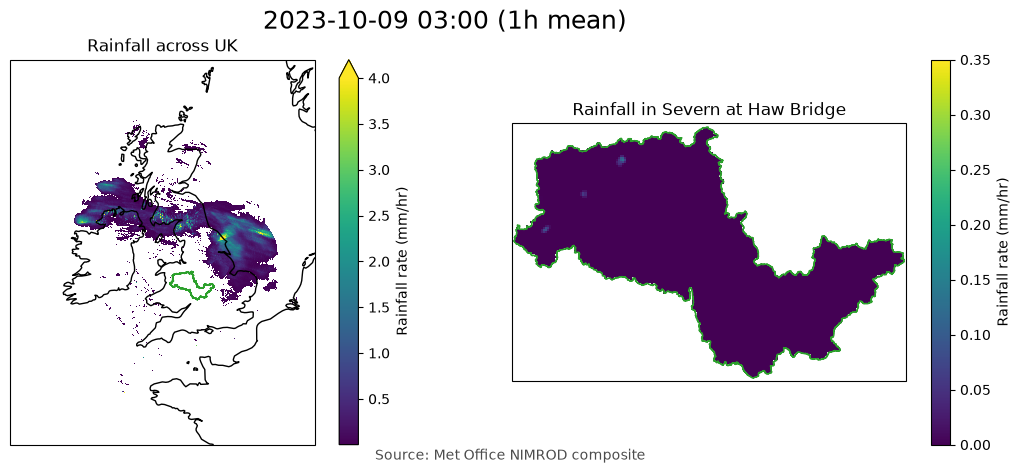

In [48]:
fig, axes = plt.subplots(1, 2, subplot_kw={'projection': bng}, figsize=(14, 5))
one_day_nimrod_clip_hourly_shifted['rainfall_rate'].where(lambda data: data > 0 ).sel(time=hour_date_time_to_examine).plot(
    ax=axes[0], vmax=4, cbar_kwargs={"label": "Rainfall rate (mm/hr)"}, transform=bng
)

catchment_masked_rainfall.sel(time=hour_date_time_to_examine)["rainfall_rate"].plot(
    ax=axes[1], vmax=0.35, cbar_kwargs={"label": "Rainfall rate (mm/hr)"}, transform=bng
)

for ax in axes:
    nrfa_shp.plot(ax=ax, facecolor="none", edgecolor="C2", transform=bng)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.coastlines()

plt.suptitle(f"{hour_date_time_to_examine} (1h mean)", size=18)
axes[0].set_title("Rainfall across UK")
axes[1].set_title("Rainfall in Severn at Haw Bridge")
fig.text(s="Source: Met Office NIMROD composite", x=.45, y=.08, c='k', alpha=.7)
# fig.savefig("../../figures/severn_catchment_subset_1h_mean.png", bbox_inches='tight', dpi=150)

### Calculate catchment average rainfall from radar data
Now that we have masked rainfall for the catchment, you may want to compute spatial and time averages of the radar field over the catchment. Below are examples of how to do that...

In [ ]:
catchment_masked_rainfall_spatial_mean = catchment_masked_rainfall.mean(dim='time')
catchment_masked_rainfall_time_mean = catchment_masked_rainfall.mean(['x', 'y'])

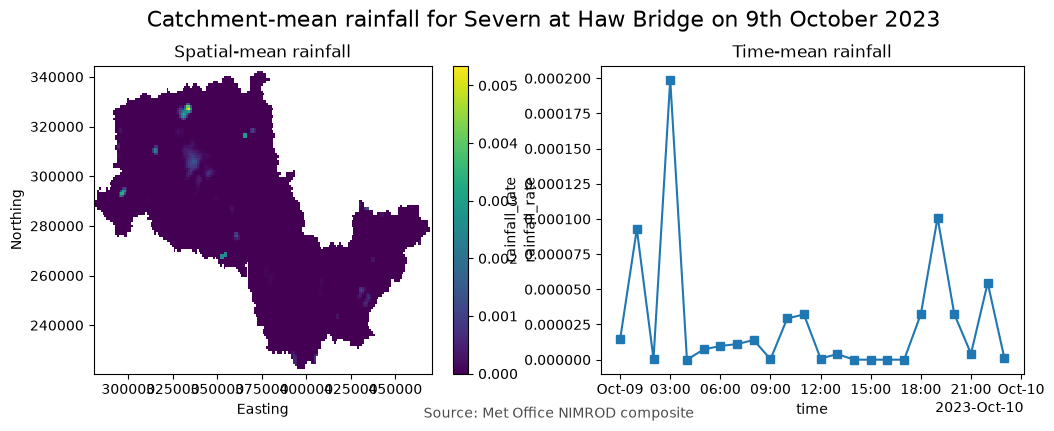

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
catchment_masked_rainfall_spatial_mean['rainfall_rate'].plot(ax=axes[0])
catchment_masked_rainfall_time_mean['rainfall_rate'].plot(marker='s', ax=axes[1])
fig.suptitle("Catchment-mean rainfall for Severn at Haw Bridge on 9th October 2023", y=1.02, size=16)
axes[0].set_title("Spatial-mean rainfall")
axes[0].set_ylabel("Northing"); axes[0].set_xlabel("Easting"); 
axes[1].set_title("Time-mean rainfall")
fig.text(s="Source: Met Office NIMROD composite", x=.4, y=.0, c='k', alpha=.7)
# fig.savefig("../../figures/catchment_mean_rainfall.png", bbox_inches='tight', dpi=150)

# 7. Advice for reading in more data
No need to unzip, the workflow introduced in this notebook will help you read them.